In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = yf.Tickers('CBA.AX BHP.AX CSL.AX WES.AX MQG.AX')
dt_tickers = ['CBA.AX', 'BHP.AX', 'CSL.AX', 'WES.AX', 'MQG.AX']
data = yf.download(dt_tickers, start="2021-01-01", end="2025-12-31")

[*********************100%***********************]  5 of 5 completed


In [3]:
info = tickers.tickers['CBA.AX'].info
print(info.keys())

for ticker, obj in tickers.tickers.items():
    info = obj.info
    print(f"{ticker}: {info['longName']} | Sector: {info['sector']} | Market Cap: {info['marketCap']}")


dict_keys(['address1', 'address2', 'city', 'state', 'zip', 'country', 'phone', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'compensationAsOfEpochDate', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'dividendRate', 'dividendYield', 'exDividendDate', 'payoutRatio', 'fiveYearAvgDividendYield', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'marketCap', 'nonDilutedMarketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'fulldayPrice', 'fulldayChange', 'fulldayChangePercent', 'priceToSalesTraili

In [4]:
close_prices = data['Close']
close_prices.head()

Ticker,BHP.AX,CBA.AX,CSL.AX,MQG.AX,WES.AX
Date,,,,,
2021-01-04,25.521431,67.473495,259.577087,115.206917,41.287464
2021-01-05,26.256371,67.054543,260.141693,114.474533,41.079067
2021-01-06,26.203035,66.788696,253.547516,111.767151,40.469898
2021-01-07,27.797379,68.142181,250.469055,113.931396,40.838604
2021-01-08,27.661058,68.988121,255.250717,115.988663,41.559990


In [5]:
returns = close_prices.pct_change().dropna()
returns.head()

Ticker,BHP.AX,CBA.AX,CSL.AX,MQG.AX,WES.AX
Date,,,,,
2021-01-05,0.028797,-0.006209,0.002175,-0.006357,-0.005047
2021-01-06,-0.002031,-0.003965,-0.025348,-0.023651,-0.014829
2021-01-07,0.060846,0.020265,-0.012142,0.019364,0.009111
2021-01-08,-0.004904,0.012414,0.019091,0.018057,0.017664
2021-01-11,-0.003643,-0.005489,-0.015343,-0.006669,-0.008872


In [6]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Mean Daily Returns:")
print(mean_returns)
print("\nCovariance Matrix:")
print(cov_matrix)


Mean Daily Returns:
Ticker
BHP.AX    0.000549
CBA.AX    0.000744
CSL.AX   -0.000237
MQG.AX    0.000545
WES.AX    0.000595
dtype: float64

Covariance Matrix:
Ticker    BHP.AX    CBA.AX    CSL.AX    MQG.AX    WES.AX
Ticker                                                  
BHP.AX  0.000259  0.000036  0.000011  0.000073  0.000030
CBA.AX  0.000036  0.000154  0.000045  0.000084  0.000072
CSL.AX  0.000011  0.000045  0.000209  0.000061  0.000048
MQG.AX  0.000073  0.000084  0.000061  0.000212  0.000086
WES.AX  0.000030  0.000072  0.000048  0.000086  0.000152


In [7]:
# Monte Carlo simulation parameters
num_portfolios = 10000
num_stocks = len(mean_returns)
trading_days = 252

# Fixed random seed so the results are the same every time the notebook runs
rng = np.random.default_rng(42)

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Randomly generate portfolio weights
    weights = rng.random(num_stocks)
    # Normalise weights to sum to 1
    weights /= np.sum(weights)
    # Save the combination of weights for later analysis
    weights_record.append(weights)

    # Calculate portfolio return in annualised terms
    portfolio_return = np.sum(mean_returns * weights) * trading_days

    # Calculate portfolio volatility
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * trading_days, weights)))

    # Sharpe ratio (assuming risk-free rate of 4% for Australia)
    sharpe_ratio = (portfolio_return - 0.04) / port_volatility

    # Results
    results[0, i] = portfolio_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio

print(results.shape)
print(results[:, :5])  # show first 5 portfolios

(3, 10000)
[[0.08656504 0.10182062 0.11410425 0.14746118 0.0938937 ]
 [0.15169582 0.14387901 0.14906136 0.16053954 0.14748388]
 [0.30696328 0.42967086 0.4971392  0.66937518 0.36542095]]


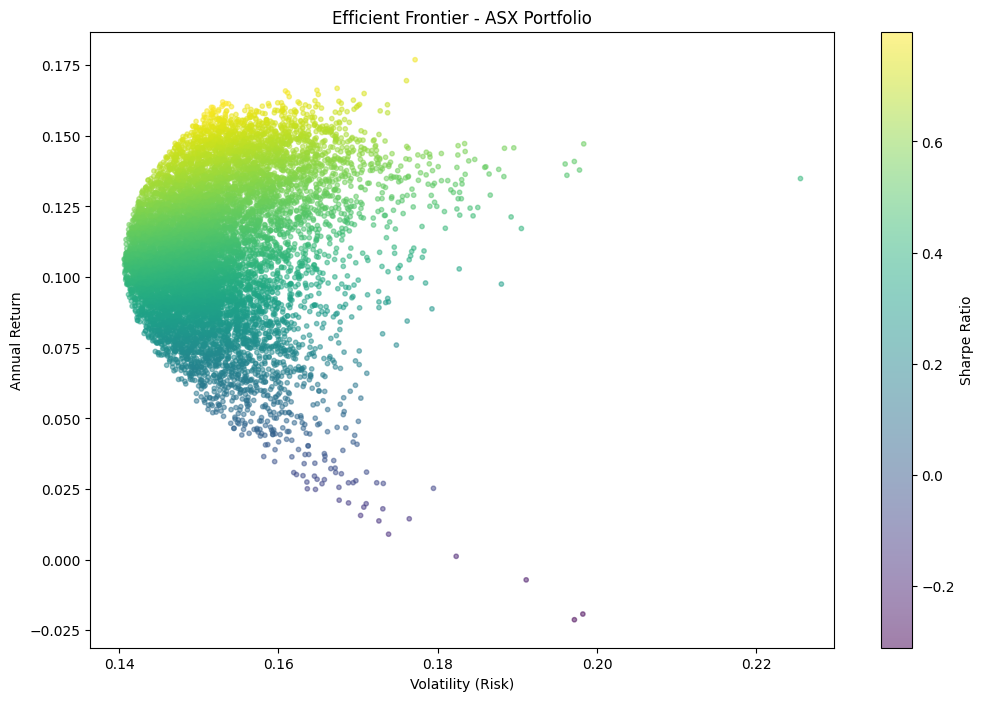

In [8]:
# Plotting the result.
plt.figure(figsize=(12, 8))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Annual Return')
plt.title('Efficient Frontier - ASX Portfolio')
plt.show()

In [9]:
# Maximum Sharpe Ratio Portfolio
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_ratio = results[2, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

print("Max Sharpe Ratio Portfolio:")
print(f"Return: {max_sharpe_return:.4f}")
print(f"Volatility: {max_sharpe_volatility:.4f}")
print(f"Sharpe Ratio: {max_sharpe_ratio:.4f}")
print("Weights:")
print(pd.Series(max_sharpe_weights, index=mean_returns.index).round(4).to_string())

Max Sharpe Ratio Portfolio:
Return: 0.1620
Volatility: 0.1530
Sharpe Ratio: 0.7973
Weights:
Ticker
BHP.AX    0.1696
CBA.AX    0.4052
CSL.AX    0.0031
MQG.AX    0.0440
WES.AX    0.3782


In [10]:
# Minimum Variance Portfolio
min_var_idx = np.argmin(results[1])
min_var_return = results[0, min_var_idx]
min_var_volatility = results[1, min_var_idx]
min_var_sharpe = results[2, min_var_idx]
min_var_weights = weights_record[min_var_idx]

print("Minimum Variance Portfolio:")
print(f"Return: {min_var_return:.4f}")
print(f"Volatility: {min_var_volatility:.4f}")
print(f"Sharpe Ratio: {min_var_sharpe:.4f}")
print("Weights:")
print(pd.Series(min_var_weights, index=mean_returns.index).round(4).to_string())

Minimum Variance Portfolio:
Return: 0.1064
Volatility: 0.1406
Sharpe Ratio: 0.4722
Weights:
Ticker
BHP.AX    0.2062
CBA.AX    0.2626
CSL.AX    0.2418
MQG.AX    0.0236
WES.AX    0.2658


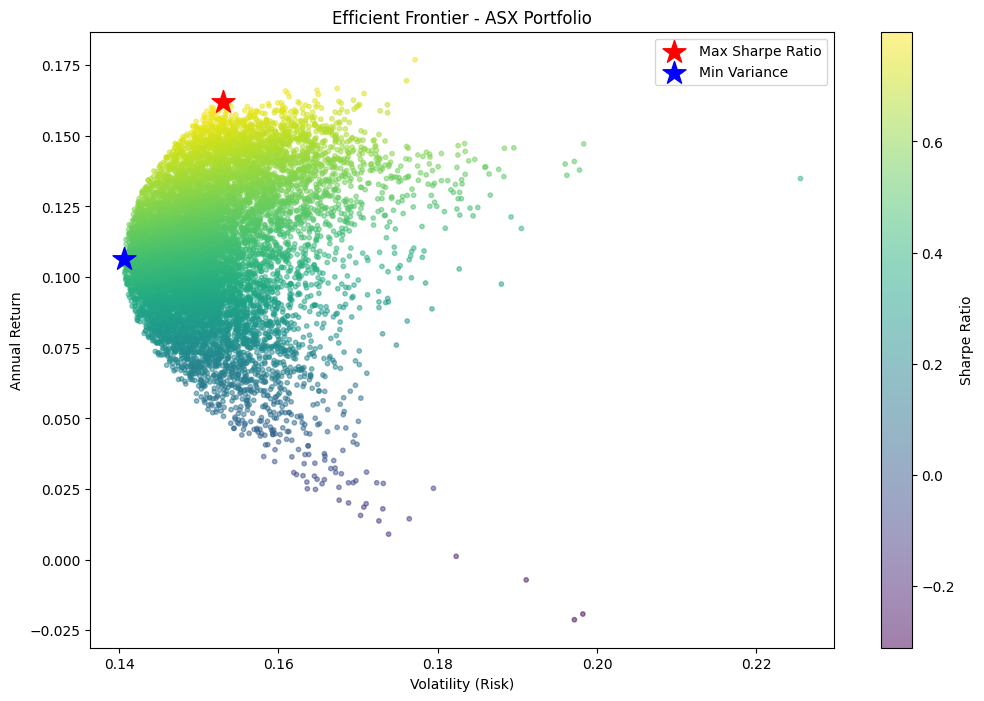

In [11]:
plt.figure(figsize=(12, 8))

# plot all portfolios
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Sharpe Ratio')

# mark max sharpe portfolio
plt.scatter(max_sharpe_volatility, max_sharpe_return, marker='*', color='red', s=300, label='Max Sharpe Ratio')

# mark minimum variance portfolio
plt.scatter(min_var_volatility, min_var_return, marker='*', color='blue', s=300, label='Min Variance')

plt.xlabel('Volatility (Risk)')
plt.ylabel('Annual Return')
plt.title('Efficient Frontier - ASX Portfolio')
plt.legend()

# Save the chart so the README can show it
Path('../images').mkdir(exist_ok=True)
plt.savefig('../images/efficient_frontier.png', bbox_inches='tight')
plt.show()